# Gaussian Beam

Visualize the analytic Gaussian beam (`lusee.BeamGauss`).

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "True"

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

import lusee

The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


In [2]:
alt_deg = 70.0   # 20 deg from zenith
sigma_deg = 20.0
gauss_beam = lusee.BeamGauss(alt_deg=alt_deg, sigma_deg=sigma_deg)

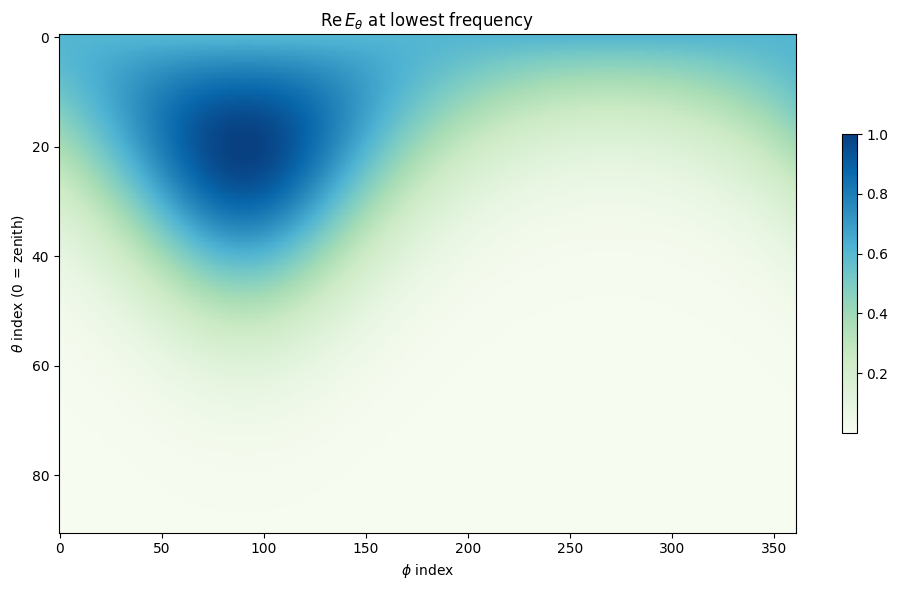

In [3]:
plt.figure(figsize=(10, 6))
plt.imshow(np.real(gauss_beam.Etheta[0, :, :]), cmap="GnBu", aspect="auto")
plt.ylabel(r"$\theta$ index (0 = zenith)")
plt.xlabel(r"$\phi$ index")
plt.title(r"$\mathrm{Re}\,E_\theta$ at lowest frequency")
plt.colorbar(shrink=0.6)
plt.tight_layout()

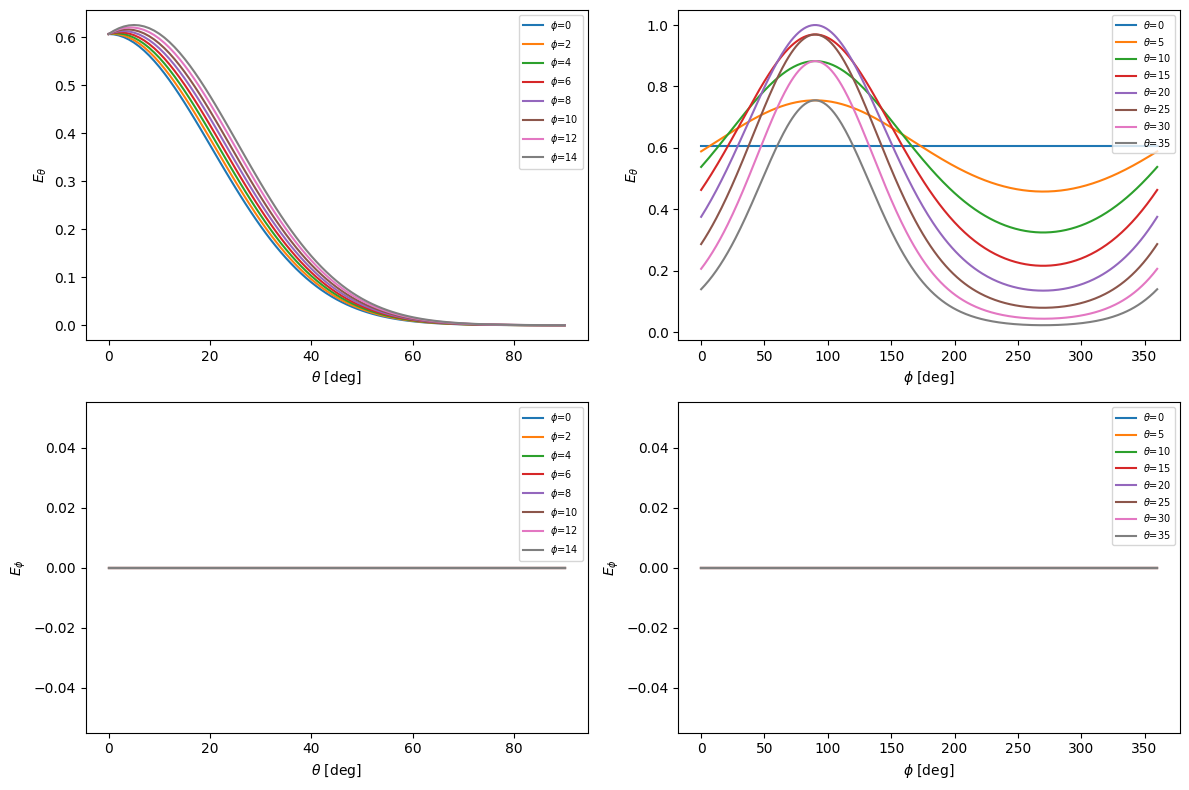

In [4]:
fig, axs = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)

for phi in np.arange(0, 15, 2):
    axs[0, 0].plot(gauss_beam.theta_deg, np.real(gauss_beam.Etheta[0, :, phi]),
                   label=f"$\\phi$={phi}")
    axs[1, 0].plot(gauss_beam.theta_deg, np.real(gauss_beam.Ephi[0, :, phi]),
                   label=f"$\\phi$={phi}")

for theta in np.arange(0, 40, 5):
    axs[0, 1].plot(gauss_beam.phi_deg, np.real(gauss_beam.Etheta[0, theta, :]),
                   label=f"$\\theta$={theta}")
    axs[1, 1].plot(gauss_beam.phi_deg, np.real(gauss_beam.Ephi[0, theta, :]),
                   label=f"$\\theta$={theta}")

axs[0, 0].set(ylabel=r"$E_\theta$", xlabel=r"$\theta$ [deg]"); axs[0, 0].legend(fontsize=7)
axs[1, 0].set(ylabel=r"$E_\phi$",   xlabel=r"$\theta$ [deg]"); axs[1, 0].legend(fontsize=7)
axs[0, 1].set(ylabel=r"$E_\theta$", xlabel=r"$\phi$ [deg]");   axs[0, 1].legend(fontsize=7)
axs[1, 1].set(ylabel=r"$E_\phi$",   xlabel=r"$\phi$ [deg]");   axs[1, 1].legend(fontsize=7)
fig.tight_layout()

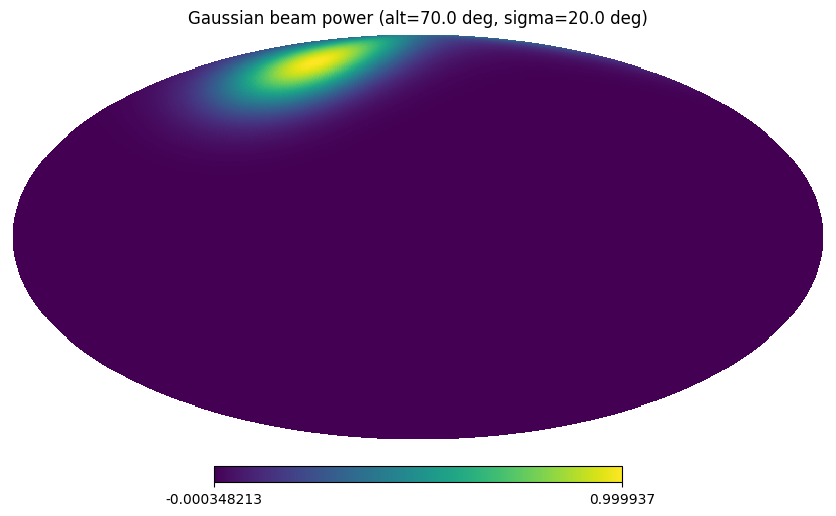

In [5]:
lmax = 200
nside = 128
hp.mollview(gauss_beam.power_hp(ellmax=lmax, Nside=nside, freq_ndx=0),
            title=f"Gaussian beam power (alt={alt_deg} deg, sigma={sigma_deg} deg)")

# Ground Fraction

The Gaussian beam is defined only over the upper hemisphere, so the
ground fraction (power below the horizon) should be ~0 to numerical
precision.

In [6]:
gain_conv = np.ones(gauss_beam.Nfreq)

dphi = float(gauss_beam.phi[1] - gauss_beam.phi[0])
dtheta = float(gauss_beam.theta[1] - gauss_beam.theta[0])
dA_theta = np.sin(np.asarray(gauss_beam.theta)) * dtheta * dphi

power0 = np.asarray(gauss_beam.power())[0, :, :]
factor = (dA_theta[:, None] * power0).sum() / (4 * np.pi)
gain_conv /= factor
gain_conv

array([33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012,
       33.46977012, 33.46977012, 33.46977012, 33.46977012, 33.46977012])

In [7]:
gain = np.asarray(gauss_beam.power()) * gain_conv[:, None, None]
f_sky = np.array([(dA_theta[:, None] * gain[i, :, :]).sum() / (4 * np.pi)
                  for i in range(gauss_beam.Nfreq)])
f_sky

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [8]:
ground = np.asarray(gauss_beam.ground_fraction())
ground

array([3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16, 3.33066907e-16, 3.33066907e-16,
       3.33066907e-16, 3.33066907e-16])

In [9]:
assert np.all(np.abs(ground) < 1e-3), "Gaussian beam should have ~0 ground power"
print("max |ground_fraction|:", float(np.max(np.abs(ground))))

max |ground_fraction|: 3.3306690738754696e-16
